In [1]:
import torch

print(torch.__version__)
print(torch.cuda.is_available())
print(torch.cuda.get_device_name(0))

2.10.0+cu128
True
Tesla T4


In [2]:

# ─────────────────────────────────────────────
# SECTION 0: Imports
# ─────────────────────────────────────────────
import gc
import time
import warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import torch
import torch.nn as nn
import torch.optim as optim
import torch.nn.functional as F
from torch.utils.data import DataLoader, TensorDataset
from tqdm import tqdm

from sklearn.preprocessing import PowerTransformer, StandardScaler
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.metrics import r2_score, mean_squared_error, mean_absolute_error

warnings.filterwarnings('ignore')
sns.set_theme(style="whitegrid")


In [3]:
 
df = pd.read_csv("/kaggle/input/datasets/mohamedismal/water-data/Combined_dataset.csv")
 

In [4]:
print("Shape:", df.shape)
df.head()
df.info()
 

Shape: (2827977, 14)
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2827977 entries, 0 to 2827976
Data columns (total 14 columns):
 #   Column                            Dtype  
---  ------                            -----  
 0   Country                           object 
 1   Area                              object 
 2   Waterbody Type                    object 
 3   Date                              object 
 4   Ammonia (mg/l)                    float64
 5   Biochemical Oxygen Demand (mg/l)  float64
 6   Dissolved Oxygen (mg/l)           float64
 7   Orthophosphate (mg/l)             float64
 8   pH (ph units)                     float64
 9   Temperature (cel)                 float64
 10  Nitrogen (mg/l)                   float64
 11  Nitrate (mg/l)                    float64
 12  CCME_Values                       float64
 13  CCME_WQI                          object 
dtypes: float64(9), object(5)
memory usage: 302.1+ MB


In [5]:
df.isnull().sum()

Country                             0
Area                                0
Waterbody Type                      0
Date                                0
Ammonia (mg/l)                      0
Biochemical Oxygen Demand (mg/l)    0
Dissolved Oxygen (mg/l)             0
Orthophosphate (mg/l)               0
pH (ph units)                       0
Temperature (cel)                   0
Nitrogen (mg/l)                     0
Nitrate (mg/l)                      0
CCME_Values                         0
CCME_WQI                            0
dtype: int64

In [6]:
df["CCME_Values"].describe()


count    2.827977e+06
mean     8.504668e+01
std      1.764665e+01
min      3.130414e+01
25%      7.715349e+01
50%      9.059609e+01
75%      1.000000e+02
max      1.000000e+02
Name: CCME_Values, dtype: float64

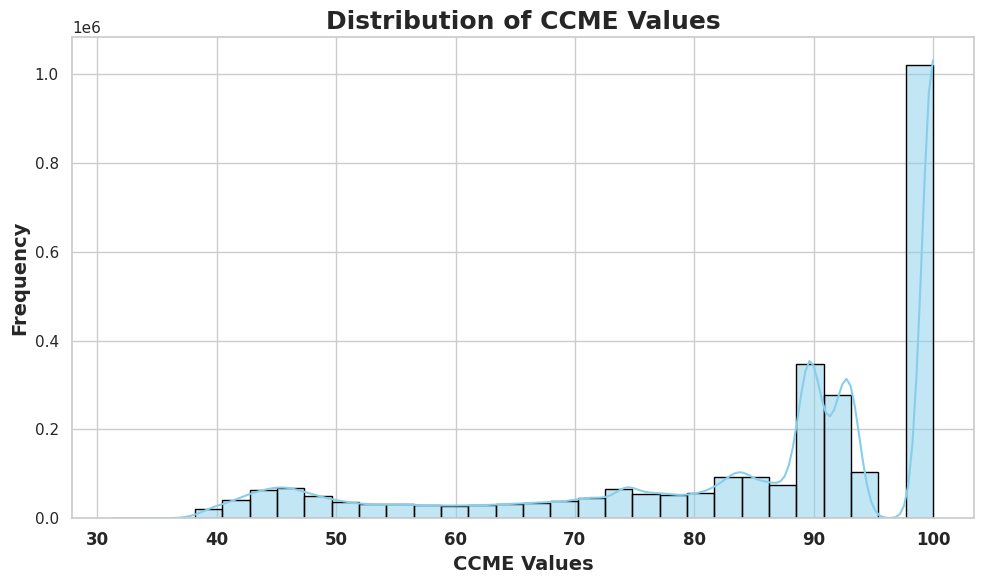

In [7]:

plt.figure(figsize=(10, 6))
sns.histplot(df["CCME_Values"].dropna(), bins=30, kde=True, color="skyblue", edgecolor="black")
plt.title("Distribution of CCME Values", fontsize=18, fontweight="bold")
plt.xlabel("CCME Values", fontsize=14, fontweight="bold")
plt.ylabel("Frequency", fontsize=14, fontweight="bold")
plt.xticks(fontsize=12, fontweight="bold")
plt.tight_layout()
plt.show()



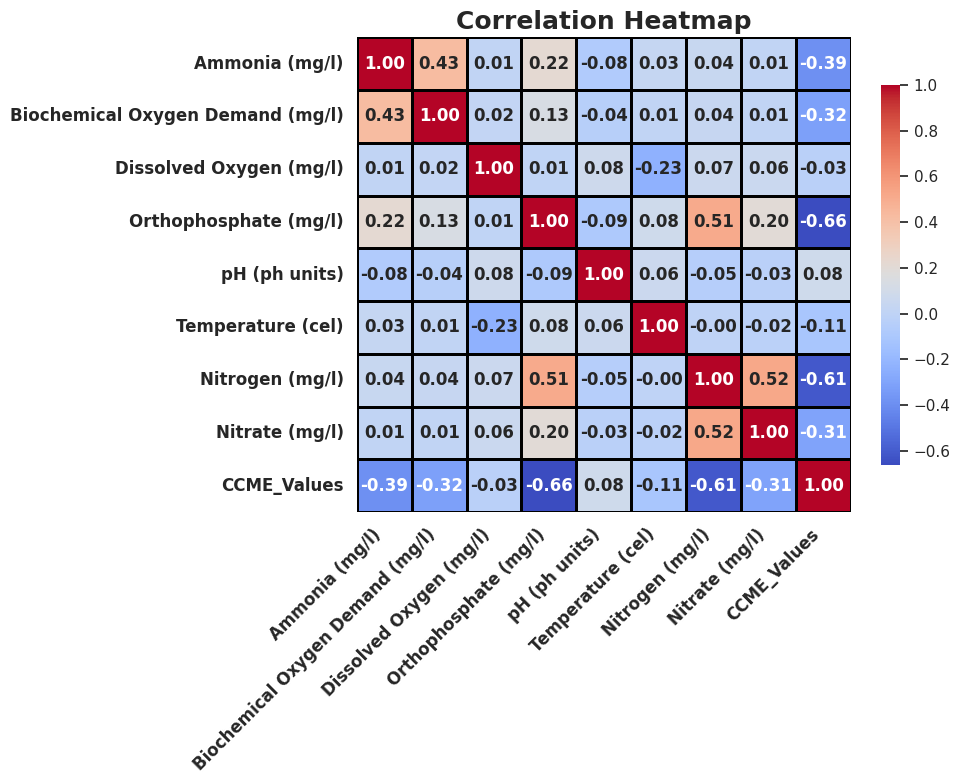

In [8]:
 
# --- Correlation Heatmap ---
corr_data = df.select_dtypes(include="number").corr()
plt.figure(figsize=(10, 8))
ax = sns.heatmap(corr_data, annot=True, cmap="coolwarm", fmt=".2f",
                 annot_kws={"size": 12, "weight": "bold"},
                 linewidths=1, linecolor="black", cbar_kws={"shrink": 0.8})
ax.set_xticklabels(ax.get_xticklabels(), fontsize=12, fontweight="bold",
                   rotation=45, ha="right")
ax.set_yticklabels(ax.get_yticklabels(), fontsize=12, fontweight="bold")
plt.title("Correlation Heatmap", fontsize=18, fontweight="bold")
plt.tight_layout(); plt.show()


In [9]:
# ─────────────────────────────────────────────
# SECTION 2: Cleaning & Feature Engineering
# ─────────────────────────────────────────────
df["Date"]        = pd.to_datetime(df["Date"], dayfirst=True, errors="coerce")
df["CCME_Values"] = pd.to_numeric(df["CCME_Values"], errors="coerce")
df["Year"]        = df["Date"].dt.year
df["Month"]       = df["Date"].dt.month

# --- Valid ranges filter ---
valid_ranges = {
    "Ammonia (mg/l)": (0, 20),
    "Biochemical Oxygen Demand (mg/l)": (0, 50),
    "Dissolved Oxygen (mg/l)": (2, 30),
    "Orthophosphate (mg/l)": (0, 10),
    "pH (ph units)": (4, 11),
    "Temperature (cel)": (0, 60),
    "Nitrogen (mg/l)": (0, 50),
    "Nitrate (mg/l)": (0, 100),
    "CCME_Values": (0, 100)
}
mask_valid = pd.Series(True, index=df.index)
for col, (low, high) in valid_ranges.items():
    mask_valid &= df[col].between(low, high, inclusive="both")

df_clean = df[mask_valid].copy().drop_duplicates()
print(f"After cleaning: {df_clean.shape[0]} rows")


After cleaning: 2724675 rows


In [10]:
# --- Waterbody Type grouping ---
df_clean['Waterbody Type'] = df_clean['Waterbody Type'].replace({
    'Marine': 'Coastal/Marine', 'Sea Water': 'Coastal/Marine',
    'Coastal': 'Coastal/Marine', 'Estuarine': 'Coastal/Marine',
    'Sewage': 'Wastewater', 'Effluent': 'Wastewater',
    'Canal': 'Artificial', 'Drainage': 'Artificial',
    'Bay': 'Minor Waterbodies', 'Artificial': 'Minor Waterbodies',
    'Transitional': 'Minor Waterbodies'
})

# ── NEW: Sin/Cos encoding للشهر (Seasonality Awareness) ──────────────────
df_clean['Month_sin'] = np.sin(2 * np.pi * df_clean['Month'] / 12)
df_clean['Month_cos'] = np.cos(2 * np.pi * df_clean['Month'] / 12)

df_encoded = pd.get_dummies(df_clean, columns=['Waterbody Type'], dtype="int")
print("Columns after encoding:", df_encoded.shape[1])



Columns after encoding: 23


In [11]:
# ─────────────────────────────────────────────
# SECTION 3: Train / Val / Test Split (Area-wise)
# ─────────────────────────────────────────────
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Using device: {device}")


df_encoded['Date'] = pd.to_datetime(df_encoded['Date'], dayfirst=True, errors='coerce')
df_encoded = df_encoded.sort_values(by=['Area', 'Date']).reset_index(drop=True)

unique_areas = df_encoded['Area'].unique()
np.random.seed(42)
np.random.shuffle(unique_areas)

train_size = int(len(unique_areas) * 0.70)
val_size   = int(len(unique_areas) * 0.15)

train_areas = unique_areas[:train_size]
val_areas   = unique_areas[train_size:train_size + val_size]
test_areas  = unique_areas[train_size + val_size:]

df_train_final = df_encoded[df_encoded['Area'].isin(train_areas)].copy()
df_val_final   = df_encoded[df_encoded['Area'].isin(val_areas)].copy()
df_test_final  = df_encoded[df_encoded['Area'].isin(test_areas)].copy()

print(f"Train: {len(df_train_final)} | Val: {len(df_val_final)} | Test: {len(df_test_final)}")


Using device: cuda
Train: 1931177 | Val: 390568 | Test: 402930


In [12]:
# ─────────────────────────────────────────────
# SECTION 4: Preprocessing
# ─────────────────────────────────────────────
DROP_COLS = ["CCME_WQI", "Country", "Area", "Date", "Year", "CCME_Values", "Month"]

def extract_X_y(df):
    X_df = df.drop(columns=DROP_COLS, errors='ignore')
    y_df = df["CCME_Values"].values.astype(np.float32)
    return X_df, y_df

X_train, y_train = extract_X_y(df_train_final)
X_val,   y_val   = extract_X_y(df_val_final)
X_test,  y_test  = extract_X_y(df_test_final)

# Clean column names
def clean_cols(df):
    df.columns = [c.replace(' ', '_').replace('/', '_')
                   .replace('(', '').replace(')', '') for c in df.columns]
    return df

X_train = clean_cols(X_train)
X_val   = clean_cols(X_val)
X_test  = clean_cols(X_test)

# ✅ FIX: Use reindex to safely align columns with train set.
# This handles cases where val/test splits are missing certain one-hot
# categories that exist in train (fills missing columns with 0).
X_val  = X_val.reindex(columns=X_train.columns, fill_value=0)
X_test = X_test.reindex(columns=X_train.columns, fill_value=0)

print(f"Train columns : {X_train.shape[1]}")
print(f"Val   columns : {X_val.shape[1]}  (aligned to train)")
print(f"Test  columns : {X_test.shape[1]}  (aligned to train)")

num_features = [
    "Ammonia_mg_l", "Biochemical_Oxygen_Demand_mg_l", "Dissolved_Oxygen_mg_l",
    "Orthophosphate_mg_l", "pH_ph_units", "Temperature_cel",
    "Nitrogen_mg_l", "Nitrate_mg_l"
]
cat_features = [c for c in X_train.columns if c not in num_features]

preprocessor = ColumnTransformer(transformers=[
    ('num', Pipeline([
        ('pw', PowerTransformer(method='yeo-johnson')),
        ('sc', StandardScaler())
    ]), num_features),
    ('cat', 'passthrough', cat_features)
])

X_train_proc = preprocessor.fit_transform(X_train)
X_val_proc   = preprocessor.transform(X_val)
X_test_proc  = preprocessor.transform(X_test)
print(f"Feature dim after preprocessing: {X_train.shape[1]}")
print(f"Feature dim after preprocessing: {X_train_proc.shape[1]}")


Train columns : 16
Val   columns : 16  (aligned to train)
Test  columns : 16  (aligned to train)
Feature dim after preprocessing: 16
Feature dim after preprocessing: 16


In [13]:
# ─────────────────────────────────────────────
# SECTION 5: Sliding Window Sequences
# ─────────────────────────────────────────────
SEQ_LEN = 8

def create_sequences(X_proc, y_data, areas_df, seq_length=8, stride=3):
    all_x, all_y = [], []
    areas_vals = areas_df['Area'].values
    y_vals     = y_data.values if hasattr(y_data, 'values') else y_data

    for area in tqdm(areas_df['Area'].unique(), desc="Windowing", unit="area"):
        mask    = (areas_vals == area)
        X_area  = X_proc[mask]
        y_area  = y_vals[mask]
        if len(X_area) > seq_length:
            for start in range(0, len(X_area) - seq_length + 1, stride):
                all_x.append(X_area[start:start + seq_length])
                all_y.append(y_area[start + seq_length - 1])

    return np.array(all_x, dtype=np.float32), np.array(all_y, dtype=np.float32)

X_train_seq, y_train_seq = create_sequences(X_train_proc, y_train, df_train_final,
                                             seq_length=SEQ_LEN, stride=4)
X_val_seq,   y_val_seq   = create_sequences(X_val_proc,   y_val,   df_val_final,
                                             seq_length=SEQ_LEN, stride=1)
X_test_seq,  y_test_seq  = create_sequences(X_test_proc,  y_test,  df_test_final,
                                             seq_length=SEQ_LEN, stride=1)

print(f"Train seq: {X_train_seq.shape} | Val: {X_val_seq.shape} | Test: {X_test_seq.shape}")


# ── Save sequences to disk ──
import joblib
joblib.dump(
    (X_train_seq, y_train_seq, X_val_seq, y_val_seq, X_test_seq, y_test_seq),
    "sequences.pkl"
)
print("[✔] sequences.pkl saved.")


Windowing: 100%|██████████| 9005/9005 [00:51<00:00, 173.96area/s]


Train seq: (440536, 8, 16) | Val: (348027, 8, 16) | Test: (359950, 8, 16)
[✔] sequences.pkl saved.


In [14]:
import joblib

 
X_train_seq, y_train_seq, X_val_seq, y_val_seq, X_test_seq, y_test_seq = joblib.load("sequences.pkl")

In [15]:

X_train_t = torch.FloatTensor(X_train_seq)                        # CPU – DataLoader transfers each batch
y_train_t = torch.FloatTensor(y_train_seq).unsqueeze(1)           # CPU

X_val_t   = torch.FloatTensor(X_val_seq).to(device)               # GPU – used directly
y_val_t   = torch.FloatTensor(y_val_seq).unsqueeze(1).to(device)  # GPU

X_test_t  = torch.FloatTensor(X_test_seq).to(device)              # GPU – used directly
y_test_t  = torch.FloatTensor(y_test_seq).unsqueeze(1).to(device) # GPU

train_dataset = TensorDataset(X_train_t, y_train_t)
train_loader  = DataLoader(train_dataset, batch_size=64, shuffle=True,
                           pin_memory=(device.type == 'cuda'),     
                           num_workers=0)
val_loader    = DataLoader(TensorDataset(X_val_t, y_val_t),   batch_size=64, shuffle=False)
test_loader   = DataLoader(TensorDataset(X_test_t, y_test_t), batch_size=64, shuffle=False)

print("Loaders ready.")
print(f"  Train batches : {len(train_loader)} | X_train_t device: {X_train_t.device}")
print(f"  Val   batches : {len(val_loader)}   | X_val_t   device: {X_val_t.device}")
print(f"  Test  batches : {len(test_loader)}  | X_test_t  device: {X_test_t.device}")


Loaders ready.
  Train batches : 6884 | X_train_t device: cpu
  Val   batches : 5438   | X_val_t   device: cuda:0
  Test  batches : 5625  | X_test_t  device: cuda:0


In [16]:
# ─────────────────────────────────────────────
# SECTION 7: Model Architecture
#   CNN-CRNN-M5T (from paper: Ehteram et al., 2024)
#
# Architecture (4 levels):
#   Level 1: CNN  — extracts spatial features from input
#   Level 2: Pooling — reduces spatial dimensions
#   Level 3: CRNN — clockwork RNN for temporal dependencies
#   Level 4: M5Tree — differentiable tree-based regression head
# ─────────────────────────────────────────────

# ── Level 1-2: CNN Spatial Feature Extractor ─────────────────────────────
class CNNSpatialExtractor(nn.Module):
    """
    Convolutional layers that extract spatial (cross-feature) patterns.
    Mirrors the paper's CNN component:
      - 3 convolutional layers with ReLU activation
      - 3 convolutional kernels per layer
      - Dropout = 0.50 (paper Table 2)
      - AdaptiveAvgPool for spatial downsampling (Level 2)

    Input:  [B, T, F]  →  treated as 1-D sequence over F features
    Output: [B, T, cnn_dim]
    """
    def __init__(self, input_dim, cnn_dim=64, num_conv_layers=3,
                 kernel_size=3, dropout=0.50):
        super().__init__()
        layers = []
        in_ch = input_dim
        for _ in range(num_conv_layers):
            layers += [
                nn.Conv1d(in_ch, cnn_dim, kernel_size=kernel_size,
                          padding=kernel_size // 2),  # same-padding
                nn.BatchNorm1d(cnn_dim),
                nn.ReLU(),
                nn.Dropout(dropout),
            ]
            in_ch = cnn_dim
        self.conv_block = nn.Sequential(*layers)
        # Level 2: Pooling — keep spatial dim T intact, pool feature maps
        self.pool = nn.AdaptiveAvgPool1d(1)   # pools over the feature axis

    def forward(self, x):
        # x: [B, T, F]
        B, T, F = x.shape
        # Reshape: treat time-steps as the 'sequence' dimension for Conv1d
        # Conv1d expects [B, C_in, L] — we convolve over features per time step
        x_t = x.permute(0, 2, 1)       # [B, F, T]
        out  = self.conv_block(x_t)    # [B, cnn_dim, T]
        out  = out.permute(0, 2, 1)    # [B, T, cnn_dim]
        return out


In [17]:
# ── Level 3: Clockwork RNN (CRNN) ────────────────────────────────────────
class ClockworkRNN(nn.Module):
    """
    Clockwork Recurrent Neural Network (CRNN) — paper Section 2.3.

    Divides hidden units into G groups, each with a different clock period.
    - Faster groups (small period) capture short-term dependencies.
    - Slower groups (large period) capture long-term seasonal patterns.

    A group g fires (updates its hidden state) only when
    (time_step % clock_period[g] == 0).

    Paper params: 4 hidden layers, 8 hidden units per layer, lr=0.001
    We generalise to n_groups hidden units with configurable periods.

    Input:  [B, T, input_dim]
    Output: [B, T, hidden_dim]   (all groups concatenated)
    """
    def __init__(self, input_dim, hidden_dim=64, n_groups=4, dropout=0.1):
        super().__init__()
        assert hidden_dim % n_groups == 0, \
            "hidden_dim must be divisible by n_groups"
        self.hidden_dim  = hidden_dim
        self.n_groups    = n_groups
        self.group_size  = hidden_dim // n_groups

        # Exponentially spaced clock periods: 1, 2, 4, 8 ...
        self.register_buffer(
            'clock_periods',
            torch.tensor([2 ** i for i in range(n_groups)], dtype=torch.long)
        )

        # Each group has its own input→hidden and hidden→hidden weights
        self.W_in  = nn.ModuleList([  # input projection per group
            nn.Linear(input_dim + self.group_size, self.group_size)
            for _ in range(n_groups)
        ])
        self.W_rec = nn.ModuleList([  # cross-group recurrence (from lower groups)
            nn.Linear(hidden_dim, self.group_size, bias=False)
            for _ in range(n_groups)
        ])

        self.dropout = nn.Dropout(dropout)
        self.norm    = nn.LayerNorm(hidden_dim)

    def forward(self, x):
        # x: [B, T, input_dim]
        B, T, _ = x.shape
        device  = x.device

        # Initialise hidden states for all groups
        h = torch.zeros(B, self.hidden_dim, device=device)  # [B, H]

        outputs = []
        for t in range(T):
            x_t   = x[:, t, :]          # [B, input_dim]
            h_new = h.clone()

            for g in range(self.n_groups):
                # Only update group g if t is a multiple of its clock period
                if t % self.clock_periods[g].item() == 0:
                    gs = self.group_size
                    h_g = h[:, g * gs:(g + 1) * gs]          # [B, group_size]

                    # Input gate: concat input with this group's hidden state
                    gate_in = torch.cat([x_t, h_g], dim=-1)  # [B, input_dim+gs]
                    h_g_new = torch.tanh(self.W_in[g](gate_in)
                                         + self.W_rec[g](h))  # cross-group context
                    h_new[:, g * gs:(g + 1) * gs] = h_g_new

            h = self.dropout(h_new)
            outputs.append(h.unsqueeze(1))          # [B, 1, H]

        out = torch.cat(outputs, dim=1)             # [B, T, H]
        return self.norm(out)


In [18]:
# ── Level 4: Differentiable M5 Tree Regression Head ─────────────────────
class M5TreeHead(nn.Module):
    """
    Differentiable approximation of M5 Model Tree (paper Section 2.1).

    The M5T model partitions data via decision rules and fits a linear
    regression model at each leaf node.  We implement this as a soft
    (differentiable) decision tree:
      - Each internal node applies a soft split via sigmoid.
      - Each leaf holds a linear regression model.
      - The final prediction is a weighted sum of leaf predictions,
        where weights are the routing probabilities.

    depth=3  →  8 leaves  (matches paper's pruned M5T complexity)

    Input:  [B, hidden_dim]   (pooled CRNN output)
    Output: [B, 1]
    """
    def __init__(self, input_dim, depth=3, output_dim=1):
        super().__init__()
        self.depth      = depth
        self.n_leaves   = 2 ** depth
        self.n_internal = self.n_leaves - 1

        # Internal nodes: each learns a splitting direction
        self.split_nodes = nn.Linear(input_dim, self.n_internal)

        # Leaf nodes: each is a linear regression model (M5T leaf equation)
        self.leaf_models = nn.ModuleList([
            nn.Linear(input_dim, output_dim) for _ in range(self.n_leaves)
        ])

    def forward(self, x):
        # x: [B, input_dim]
        B = x.size(0)

        # Soft routing probabilities at internal nodes
        splits = torch.sigmoid(self.split_nodes(x))  # [B, n_internal]

        # Build leaf probabilities via tree traversal
        # Leaf i routing = product of (split or 1-split) along root→leaf path
        leaf_probs = torch.ones(B, self.n_leaves, device=x.device)

        for node_idx in range(self.n_internal):
            # Children of node i are at 2i+1 (left) and 2i+2 (right)
            left_child  = 2 * node_idx + 1
            right_child = 2 * node_idx + 2

            # Which leaves are descendants of left / right child?
            left_leaves  = self._descendant_leaves(left_child)
            right_leaves = self._descendant_leaves(right_child)

            s = splits[:, node_idx:node_idx + 1]   # [B, 1]
            leaf_probs[:, left_leaves]  *= s
            leaf_probs[:, right_leaves] *= (1 - s)

        # Leaf predictions (linear regression at each leaf)
        leaf_preds = torch.stack(
            [self.leaf_models[i](x) for i in range(self.n_leaves)],
            dim=1
        )  # [B, n_leaves, output_dim]

        # Weighted sum: ∑ P(leaf_i) * leaf_model_i(x)
        out = (leaf_probs.unsqueeze(-1) * leaf_preds).sum(dim=1)  # [B, output_dim]
        return out

    def _descendant_leaves(self, node_idx):
        """Return leaf indices that are descendants of the given node."""
        if node_idx >= self.n_internal:   # it IS a leaf
            return [node_idx - self.n_internal]
        left  = self._descendant_leaves(2 * node_idx + 1)
        right = self._descendant_leaves(2 * node_idx + 2)
        return left + right


In [19]:
# ── Full CNN-CRNN-M5T Model ───────────────────────────────────────────────
class CNN_CRNN_M5T(nn.Module):
    """
    CNN-CRNN-M5T: Hybrid Deep Learning Model for Water Quality Index Prediction.
    Source: Ehteram et al. (2024), Ecological Indicators 160, 111806.

    4-level pipeline:
        Input
          │
          ▼
        Level 1 — CNN (3 conv layers, ReLU, dropout=0.5)
                   ↓  Extracts spatial/cross-feature patterns
        Level 2 — Pooling (AdaptiveAvgPool — reduces feature maps)
                   ↓
        Level 3 — CRNN (Clockwork RNN: 4 groups, exp. clock periods)
                   ↓  Captures temporal dependencies & seasonal patterns
        Level 4 — M5Tree Head (soft decision tree + leaf linear models)
                   ↓  Rule-based regression, enhances interpretability
          Output (CCME_Values, continuous 0-100)

    Maintains `last_attn_weights` attribute (set to None) for backward
    compatibility with the XAI/SHAP sections of this notebook.
    """
    def __init__(self, input_dim,
                 cnn_dim=64,       num_conv_layers=3,  cnn_dropout=0.50,
                 crnn_hidden=128,  n_groups=4,         crnn_dropout=0.10,
                 tree_depth=3,     output_dim=1):
        super().__init__()
        self.input_dim = input_dim

        # Level 1-2: CNN spatial extractor
        self.cnn = CNNSpatialExtractor(
            input_dim=input_dim,
            cnn_dim=cnn_dim,
            num_conv_layers=num_conv_layers,
            kernel_size=3,
            dropout=cnn_dropout
        )

        # Level 3: Clockwork RNN
        self.crnn = ClockworkRNN(
            input_dim=cnn_dim,
            hidden_dim=crnn_hidden,
            n_groups=n_groups,
            dropout=crnn_dropout
        )

        # Temporal pooling: average over time → [B, crnn_hidden]
        self.temporal_pool = nn.AdaptiveAvgPool1d(1)

        # Level 4: M5 Tree regression head
        self.m5tree = M5TreeHead(
            input_dim=crnn_hidden,
            depth=tree_depth,
            output_dim=output_dim
        )

        # For backward-compatibility with XAI section (was cross-attention weights)
        self.last_attn_weights = None

    def forward(self, x):
        # x: [B, T, F]

        # Level 1-2: CNN spatial feature extraction
        cnn_out = self.cnn(x)           # [B, T, cnn_dim]

        # Level 3: CRNN temporal processing
        crnn_out = self.crnn(cnn_out)   # [B, T, crnn_hidden]

        # Temporal pooling over T → [B, crnn_hidden]
        pooled = self.temporal_pool(
            crnn_out.permute(0, 2, 1)   # [B, crnn_hidden, T]
        ).squeeze(-1)                   # [B, crnn_hidden]

        # Save a pseudo-attention map for XAI compatibility
        # (CRNN hidden states over time — shape [B, T, T] approximation)
        with torch.no_grad():
            T = crnn_out.size(1)
            # Cosine similarity between time steps as attention proxy
            crnn_n = F.normalize(crnn_out, dim=-1)        # [B, T, H]
            self.last_attn_weights = torch.bmm(
                crnn_n, crnn_n.transpose(1, 2)            # [B, T, T]
            ).detach()

        # Level 4: M5 Tree regression
        out = self.m5tree(pooled)       # [B, 1]
        return out


# ── Instantiate the model ─────────────────────────────────────────────────
input_size = X_train_seq.shape[2]
output_dim = 1

model = CNN_CRNN_M5T(
    input_dim=input_size,
    cnn_dim=64,          # CNN feature maps (paper: 3 kernels per layer)
    num_conv_layers=3,   # paper: 3 convolution layers
    cnn_dropout=0.50,    # paper Table 2: Dropout=0.50
    crnn_hidden=128,     # paper: 4 hidden layers × 8 units → 128 total
    n_groups=4,          # CRNN groups with clock periods 1,2,4,8
    crnn_dropout=0.10,
    tree_depth=3,        # 8 leaves → matches M5T complexity in paper
    output_dim=output_dim
).to(device)

num_params = sum(p.numel() for p in model.parameters())
print(f"\nModel: CNN-CRNN-M5T (Ehteram et al., 2024)")
print(f"Parameters: {num_params:,}")
print(f"Task: Regression → predicting CCME_Values (0-100 continuous)")
print()
print("Architecture:")
print(f"  Level 1-2 CNN  : {input_size} → {64} (×3 conv, ReLU, dropout=0.5)")
print(f"  Level 3 CRNN   : 64 → 128  (4 groups, clock periods 1,2,4,8)")
print(f"  Level 4 M5Tree : 128 → 1   (depth=3, 8 leaves, soft routing)")



Model: CNN-CRNN-M5T (Ehteram et al., 2024)
Parameters: 59,215
Task: Regression → predicting CCME_Values (0-100 continuous)

Architecture:
  Level 1-2 CNN  : 16 → 64 (×3 conv, ReLU, dropout=0.5)
  Level 3 CRNN   : 64 → 128  (4 groups, clock periods 1,2,4,8)
  Level 4 M5Tree : 128 → 1   (depth=3, 8 leaves, soft routing)


In [20]:
# ── XAI compatibility note ────────────────────────────────────────────────
# The CNN-CRNN-M5T model stores a cosine-similarity proxy of temporal
# attention in `model.last_attn_weights` (shape [B, T, T]).
# This enables the Attention Rollout section (SECTION 15) to run
# without changes — it visualises WHICH time step the CRNN considers
# most similar to every other time step (temporal coherence map).
print("[Model ready] CNN-CRNN-M5T instantiated.")
print(f"  Inputs : [B, T={X_train_seq.shape[1]}, F={X_train_seq.shape[2]}]")
print(f"  Output : [B, 1]  →  CCME_Values")


[Model ready] CNN-CRNN-M5T instantiated.
  Inputs : [B, T=8, F=16]
  Output : [B, 1]  →  CCME_Values


In [21]:
# ─────────────────────────────────────────────
# SECTION 8: Training Setup
# ─────────────────────────────────────────────

# Loss function
criterion = nn.MSELoss()

# Optimizer
optimizer = optim.AdamW(
    model.parameters(),
    lr=1e-3,
    weight_decay=5e-5
)

# Learning rate scheduler (OneCycleLR)
scheduler = optim.lr_scheduler.OneCycleLR(
    optimizer,
    max_lr=1e-3,
    steps_per_epoch=len(train_loader),
    epochs=100,
    pct_start=0.1,
    anneal_strategy='cos',
    div_factor=25,
    final_div_factor=1e4
)

# Training hyperparameters
NUM_EPOCHS    = 100
PATIENCE      = 6
MIN_DELTA     = 0.01
GRADIENT_CLIP = 1.0

print(f"Criterion    : {criterion.__class__.__name__}")
print(f"Optimizer    : AdamW  (lr=1e-3, weight_decay=5e-5)")
print(f"Scheduler    : OneCycleLR  (max_lr=1e-3, epochs={NUM_EPOCHS})")
print(f"Early Stop   : patience={PATIENCE}, min_delta={MIN_DELTA}")
print(f"Gradient Clip: {GRADIENT_CLIP}")


Criterion    : MSELoss
Optimizer    : AdamW  (lr=1e-3, weight_decay=5e-5)
Scheduler    : OneCycleLR  (max_lr=1e-3, epochs=100)
Early Stop   : patience=6, min_delta=0.01
Gradient Clip: 1.0


In [22]:
# ─────────────────────────────────────────────
# SECTION 8b: Checkpoint Utilities
# ─────────────────────────────────────────────
import os

CHECKPOINT_DIR  = "./checkpoints"
CHECKPOINT_PATH = os.path.join(CHECKPOINT_DIR, "checkpoint_latest.pth")
BEST_MODEL_PATH = os.path.join(CHECKPOINT_DIR, "best_model.pth")
os.makedirs(CHECKPOINT_DIR, exist_ok=True)


def save_checkpoint(epoch, model, optimizer, scheduler,
                    best_val_loss, path=CHECKPOINT_PATH,
                    train_losses=None, val_losses=None, learning_rates=None):
    """
    Save a full training checkpoint.
    Includes model weights, optimizer state, scheduler state,
    current epoch, best validation score, AND training history lists.
    Uses atomic write (tmp → rename) to avoid corruption on long runs.
    """
    tmp_path   = path + ".tmp"
    checkpoint = {
        "epoch":           epoch,
        "model_state":     model.state_dict(),
        "optimizer_state": optimizer.state_dict(),
        "scheduler_state": scheduler.state_dict() if scheduler else None,
        "best_val_loss":   best_val_loss,
        # ── Training history (for learning curves) ──
        "train_losses":    train_losses   if train_losses   is not None else [],
        "val_losses":      val_losses     if val_losses     is not None else [],
        "learning_rates":  learning_rates if learning_rates is not None else [],
    }
    torch.save(checkpoint, tmp_path)
    os.replace(tmp_path, path)   # atomic: prevents corrupt files on crash


def load_checkpoint(path, model, optimizer, scheduler=None):
    """
    Load checkpoint and restore all training state including history lists.
    Returns (start_epoch, best_val_loss, train_losses, val_losses, learning_rates).
    If checkpoint does not exist → returns defaults to start fresh.
    """
    if not os.path.exists(path):
        print("[Checkpoint] No checkpoint found – starting from scratch.")
        return 0, float('inf'), [], [], []

    print(f"[Checkpoint] Resuming from: {path}")
    ckpt = torch.load(path, map_location=device, weights_only=False)

    model.load_state_dict(ckpt["model_state"])
    optimizer.load_state_dict(ckpt["optimizer_state"])

    if scheduler is not None and ckpt.get("scheduler_state") is not None:
        scheduler.load_state_dict(ckpt["scheduler_state"])
        print("[Checkpoint] Scheduler state restored.")

    start_epoch    = ckpt["epoch"] + 1       # resume AFTER the saved epoch
    best_val_loss  = ckpt["best_val_loss"]
    train_losses   = ckpt.get("train_losses",   [])
    val_losses     = ckpt.get("val_losses",     [])
    learning_rates = ckpt.get("learning_rates", [])

    print(f"[Checkpoint] Resumed at epoch {start_epoch} | "
          f"Best Val MSE so far: {best_val_loss:.4f} | "
          f"History loaded: {len(train_losses)} epochs")
    return start_epoch, best_val_loss, train_losses, val_losses, learning_rates


print("[Checkpoint] Utilities ready.")
print(f"  Latest checkpoint : {CHECKPOINT_PATH}")
print(f"  Best model        : {BEST_MODEL_PATH}")


[Checkpoint] Utilities ready.
  Latest checkpoint : ./checkpoints/checkpoint_latest.pth
  Best model        : ./checkpoints/best_model.pth


In [23]:
# ─────────────────────────────────────────────
# SECTION 9: Training Loop (Regression)
# ─────────────────────────────────────────────

start_epoch, best_val_loss, train_losses, val_losses, learning_rates = load_checkpoint(
    CHECKPOINT_PATH, model, optimizer, scheduler
)
patience_counter = 0
best_model_state = None

print("\n" + "="*80)
print(f"{'Epoch':<8}|{'Train Loss (MSE)':<18}|{'Val Loss (MSE)':<18}|{'LR':<10}")
print("-" * 80)

for epoch in range(start_epoch, NUM_EPOCHS):
    model.train()
    tr_loss, tr_total = 0.0, 0

    loop = tqdm(train_loader, leave=False, desc=f"Epoch {epoch+1}/{NUM_EPOCHS}")
    for batch_x, batch_y in loop:
         
        batch_x = batch_x.to(device, non_blocking=True)
        batch_y = batch_y.to(device, non_blocking=True)

        logits = model(batch_x)
        loss   = criterion(logits, batch_y)

        optimizer.zero_grad()
        loss.backward()
        torch.nn.utils.clip_grad_norm_(model.parameters(), GRADIENT_CLIP)
        optimizer.step()

        tr_loss  += loss.item() * batch_y.size(0)
        tr_total += batch_y.size(0)
        loop.set_postfix({'loss': f'{loss.item():.4f}'})
        scheduler.step()

    tr_loss /= tr_total
    train_losses.append(tr_loss)

    model.eval()
    v_loss, v_total = 0.0, 0
    with torch.no_grad():
        for batch_x, batch_y in val_loader:
            # val tensors already on device — no .to(device) needed
            logits = model(batch_x)
            loss   = criterion(logits, batch_y)
            v_loss += loss.item() * batch_y.size(0)
            v_total += batch_y.size(0)

    v_loss /= v_total
    val_losses.append(v_loss)

    current_lr = optimizer.param_groups[0]['lr']
    learning_rates.append(current_lr)

    print(f"{epoch+1:<8}|{tr_loss:<18.4f}|{v_loss:<18.4f}|{current_lr:<10.6f}")

    # ── Save latest checkpoint WITH full history ──
    save_checkpoint(epoch, model, optimizer, scheduler, best_val_loss,
                    path=CHECKPOINT_PATH,
                    train_losses=train_losses,
                    val_losses=val_losses,
                    learning_rates=learning_rates)

    if v_loss < best_val_loss - MIN_DELTA:
        best_val_loss = v_loss
        patience_counter = 0
        best_model_state = {k: v.clone() for k, v in model.state_dict().items()}
        save_checkpoint(epoch, model, optimizer, scheduler, best_val_loss,
                        path=BEST_MODEL_PATH,
                        train_losses=train_losses,
                        val_losses=val_losses,
                        learning_rates=learning_rates)
        print(f"   ✔ Best model saved! (Val Loss: {v_loss:.4f})")
    else:
        patience_counter += 1
        if patience_counter >= PATIENCE:
            print(f"\n⚡ Early stopping at epoch {epoch+1}")
            break

print("="*80)
print(f"Best Val Loss: {best_val_loss:.4f}")
print(f"Total epochs trained: {len(train_losses)}")
checkpoint = torch.load(BEST_MODEL_PATH, weights_only=False)
model.load_state_dict(checkpoint["model_state"])


[Checkpoint] No checkpoint found – starting from scratch.

Epoch   |Train Loss (MSE)  |Val Loss (MSE)    |LR        
--------------------------------------------------------------------------------


1       |3584.3558         |182.4825          |0.000063  
   ✔ Best model saved! (Val Loss: 182.4825)


2       |61.1343           |54.3943           |0.000132  
   ✔ Best model saved! (Val Loss: 54.3943)


3       |24.9697           |42.6355           |0.000238  
   ✔ Best model saved! (Val Loss: 42.6355)


4       |18.3097           |42.1623           |0.000372  
   ✔ Best model saved! (Val Loss: 42.1623)


...

24      |7.7043            |17.6787           |0.000941  


25      |7.6701            |16.9197           |0.000933  


26      |7.5757            |14.1044           |0.000924  


27      |7.5646            |14.9867           |0.000915  

⚡ Early stopping at epoch 27
Best Val Loss: 12.8960
Total epochs trained: 27


<All keys matched successfully>

In [24]:

# ─────────────────────────────────────────────
# SECTION 10: Test Evaluation
# ─────────────────────────────────────────────
model.eval()
t_loss, t_total = 0.0, 0
t_preds, t_targets = [], []

with torch.no_grad():
    for batch_x, batch_y in test_loader:
        out    = model(batch_x)
        loss   = criterion(out, batch_y)
        t_loss += loss.item() * batch_y.size(0)
        
        t_total += batch_y.size(0)
        t_preds.extend(out.cpu().numpy().flatten())
        t_targets.extend(batch_y.cpu().numpy().flatten())

t_preds = np.array(t_preds)
t_targets = np.array(t_targets)

test_mse = mean_squared_error(t_targets, t_preds)
test_rmse = np.sqrt(test_mse)
test_mae = mean_absolute_error(t_targets, t_preds)
test_r2 = r2_score(t_targets, t_preds)

print(f"\nTest MSE:  {test_mse:.4f}")
print(f"Test RMSE: {test_rmse:.4f}")
print(f"Test MAE:  {test_mae:.4f}")
print(f"Test R2:   {test_r2:.4f}")




Test MSE:  13.1089
Test RMSE: 3.6206
Test MAE:  3.1330
Test R2:   0.9516


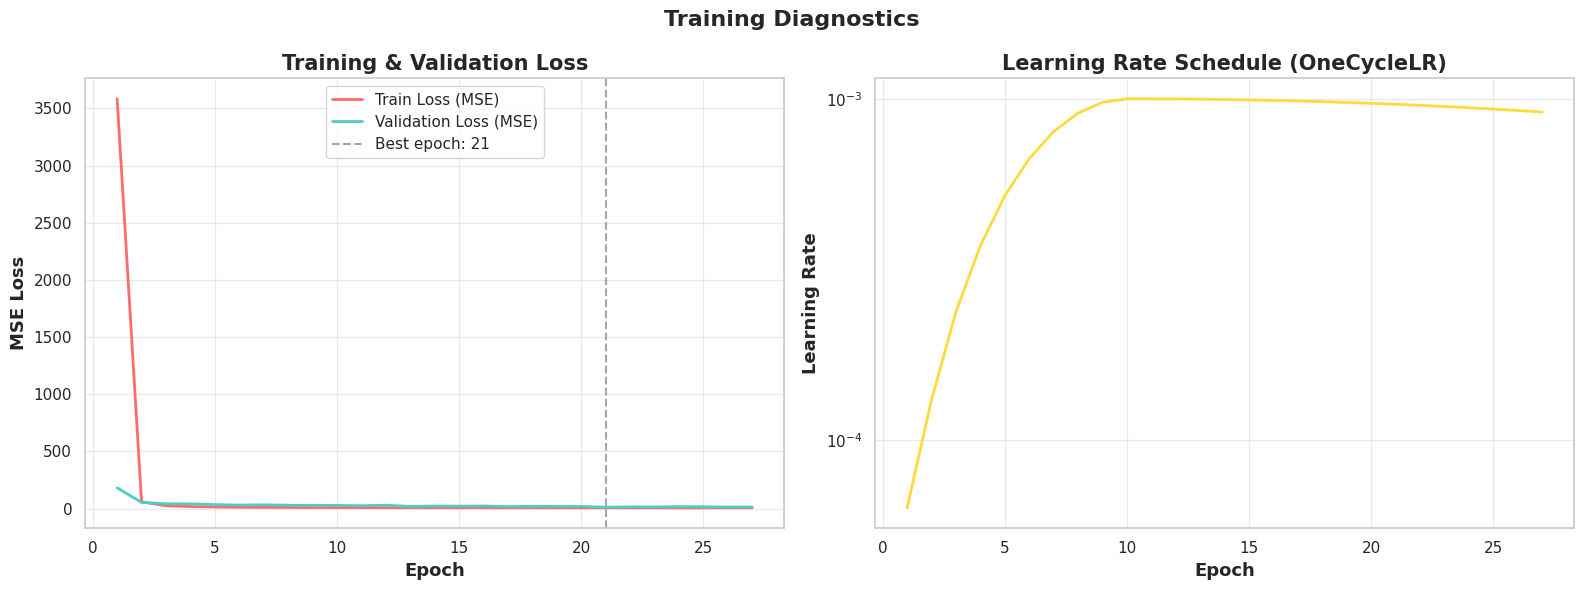

Best Val Loss: 12.8960 at epoch 21
Final Train Loss: 7.5646
Final Val Loss:   14.9867


In [25]:
# ─────────────────────────────────────────────
# SECTION 11: Training Curves
# ─────────────────────────────────────────────
# Note: train_losses / val_losses / learning_rates are either from the
# current run OR loaded from checkpoint — both cases are handled.

epochs_range = range(1, len(train_losses) + 1)

fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# ── Plot 1: Train vs Val Loss ──
axes[0].plot(epochs_range, train_losses, label='Train Loss (MSE)',
             color='#FF6B6B', linewidth=2)
axes[0].plot(epochs_range, val_losses, label='Validation Loss (MSE)',
             color='#4ECDC4', linewidth=2)
axes[0].set_title('Training & Validation Loss', fontsize=15, fontweight='bold')
axes[0].set_xlabel('Epoch', fontsize=13, fontweight='bold')
axes[0].set_ylabel('MSE Loss', fontsize=13, fontweight='bold')
axes[0].legend(fontsize=12)
axes[0].grid(True, alpha=0.4)

# Mark best epoch (lowest val loss)
best_epoch = int(val_losses.index(min(val_losses))) + 1
axes[0].axvline(x=best_epoch, color='gray', linestyle='--', alpha=0.7,
                label=f'Best epoch: {best_epoch}')
axes[0].legend(fontsize=11)

# ── Plot 2: Learning Rate Schedule ──
axes[1].plot(epochs_range, learning_rates, color='#FFD93D', linewidth=2)
axes[1].set_title('Learning Rate Schedule (OneCycleLR)', fontsize=15, fontweight='bold')
axes[1].set_xlabel('Epoch', fontsize=13, fontweight='bold')
axes[1].set_ylabel('Learning Rate', fontsize=13, fontweight='bold')
axes[1].set_yscale('log')
axes[1].grid(True, alpha=0.4)

plt.suptitle('Training Diagnostics', fontsize=16, fontweight='bold')
plt.tight_layout()
plt.savefig('learning_curve.png', dpi=300)
plt.show()

print(f"Best Val Loss: {min(val_losses):.4f} at epoch {best_epoch}")
print(f"Final Train Loss: {train_losses[-1]:.4f}")
print(f"Final Val Loss:   {val_losses[-1]:.4f}")


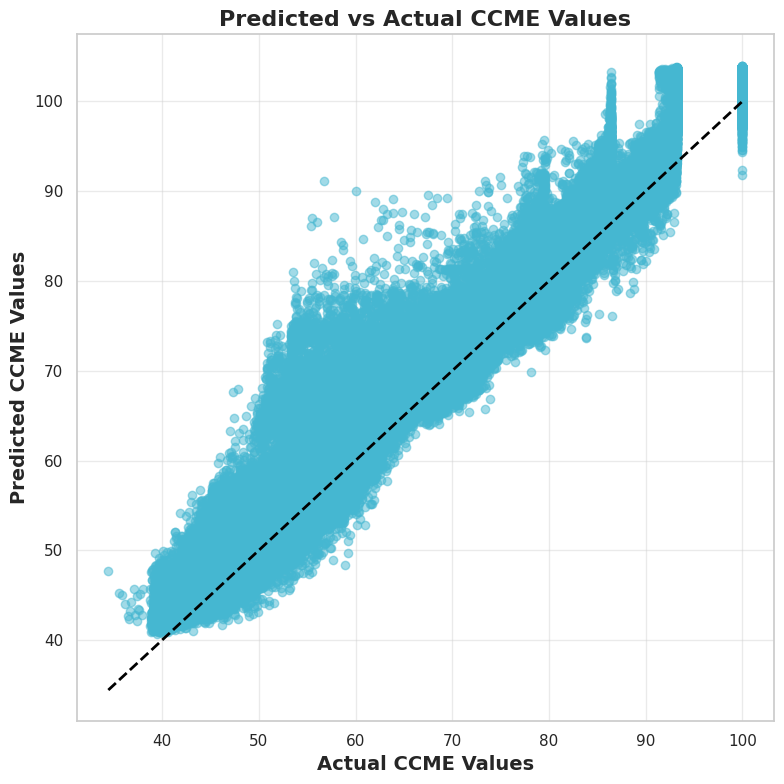

In [26]:

# ─────────────────────────────────────────────
# SECTION 12: Parity Plot (Predicted vs Actual)
# ─────────────────────────────────────────────
plt.figure(figsize=(8, 8))
plt.scatter(t_targets, t_preds, alpha=0.5, color='#45B7D1')
plt.plot([min(t_targets), max(t_targets)], [min(t_targets), max(t_targets)], color='black', linestyle='--', linewidth=2)
plt.title('Predicted vs Actual CCME Values', fontsize=16, fontweight='bold')
plt.xlabel('Actual CCME Values', fontsize=14, fontweight='bold')
plt.ylabel('Predicted CCME Values', fontsize=14, fontweight='bold')
plt.grid(True, alpha=0.4)
plt.tight_layout()
plt.savefig('parity_plot.png', dpi=300)
plt.show()



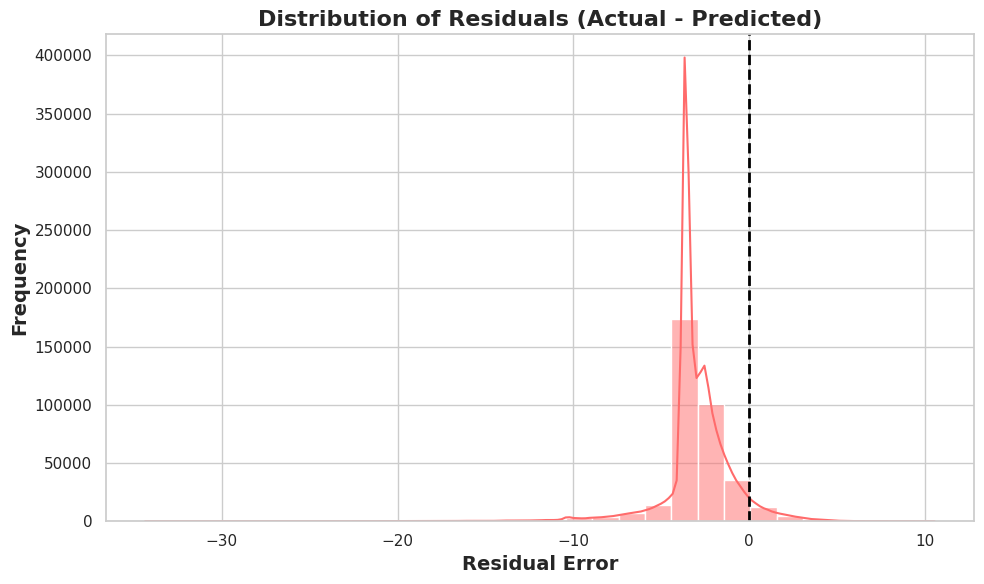

In [27]:

# ─────────────────────────────────────────────
# SECTION 13: Residual Distribution Plot
# ─────────────────────────────────────────────
residuals = t_targets - t_preds

plt.figure(figsize=(10, 6))
sns.histplot(residuals, kde=True, bins=30, color="#FF6B6B")
plt.axvline(x=0, color='black', linestyle='--', linewidth=2)
plt.title('Distribution of Residuals (Actual - Predicted)', fontsize=16, fontweight='bold')
plt.xlabel('Residual Error', fontsize=14, fontweight='bold')
plt.ylabel('Frequency', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('residuals_plot.png', dpi=300)
plt.show()




  REGRESSION METRICS — CCME_Values Prediction
  Metric   Value                                      Description
     MSE 13.1089   Mean Squared Error – average squared deviation
    RMSE  3.6206 Root Mean Squared Error – in original CCME units
     MAE  3.1330 Mean Absolute Error – average absolute deviation
R² Score  0.9516 Coefficient of Determination – 1.0 = perfect fit


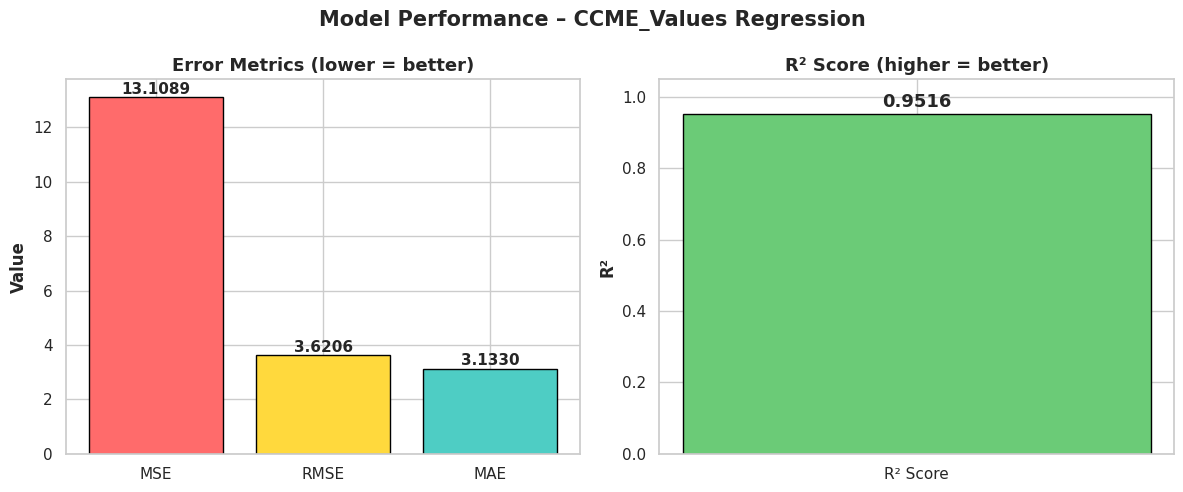

In [28]:
# ─────────────────────────────────────────────
# SECTION 14: Regression Metrics Summary Table
# ─────────────────────────────────────────────
import pandas as pd

metrics_df = pd.DataFrame({
    'Metric': ['MSE', 'RMSE', 'MAE', 'R² Score'],
    'Value':  [test_mse, test_rmse, test_mae, test_r2],
    'Description': [
        'Mean Squared Error – average squared deviation',
        'Root Mean Squared Error – in original CCME units',
        'Mean Absolute Error – average absolute deviation',
        'Coefficient of Determination – 1.0 = perfect fit'
    ]
})
metrics_df['Value'] = metrics_df['Value'].round(4)

print("\n" + "="*60)
print("  REGRESSION METRICS — CCME_Values Prediction")
print("="*60)
print(metrics_df.to_string(index=False))
print("="*60)

# Visual bar chart of error metrics (lower is better)
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

error_names  = ['MSE', 'RMSE', 'MAE']
error_values = [test_mse, test_rmse, test_mae]
axes[0].bar(error_names, error_values, color=['#FF6B6B', '#FFD93D', '#4ECDC4'],
            edgecolor='black')
axes[0].set_title('Error Metrics (lower = better)', fontsize=13, fontweight='bold')
axes[0].set_ylabel('Value', fontsize=12, fontweight='bold')
for i, v in enumerate(error_values):
    axes[0].text(i, v + 0.01 * max(error_values), f'{v:.4f}',
                 ha='center', fontsize=11, fontweight='bold')

axes[1].bar(['R² Score'], [test_r2], color='#6BCB77', edgecolor='black')
axes[1].set_ylim(0, 1.05)
axes[1].set_title('R² Score (higher = better)', fontsize=13, fontweight='bold')
axes[1].set_ylabel('R²', fontsize=12, fontweight='bold')
axes[1].text(0, test_r2 + 0.02, f'{test_r2:.4f}', ha='center',
             fontsize=13, fontweight='bold')

plt.suptitle('Model Performance – CCME_Values Regression', fontsize=15, fontweight='bold')
plt.tight_layout()
plt.savefig('regression_metrics.png', dpi=300, bbox_inches='tight')
plt.show()



[XAI] Extracting Attention Rollout Heatmaps...
['Ammonia_mg_l', 'Biochemical_Oxygen_Demand_mg_l', 'Dissolved_Oxygen_mg_l', 'Orthophosphate_mg_l', 'pH_ph_units', 'Temperature_cel', 'Nitrogen_mg_l', 'Nitrate_mg_l', 'Month_sin', 'Month_cos', 'Waterbody_Type_Artificial', 'Waterbody_Type_Coastal_Marine', 'Waterbody_Type_Lake', 'Waterbody_Type_Minor_Waterbodies', 'Waterbody_Type_River', 'Waterbody_Type_Wastewater']


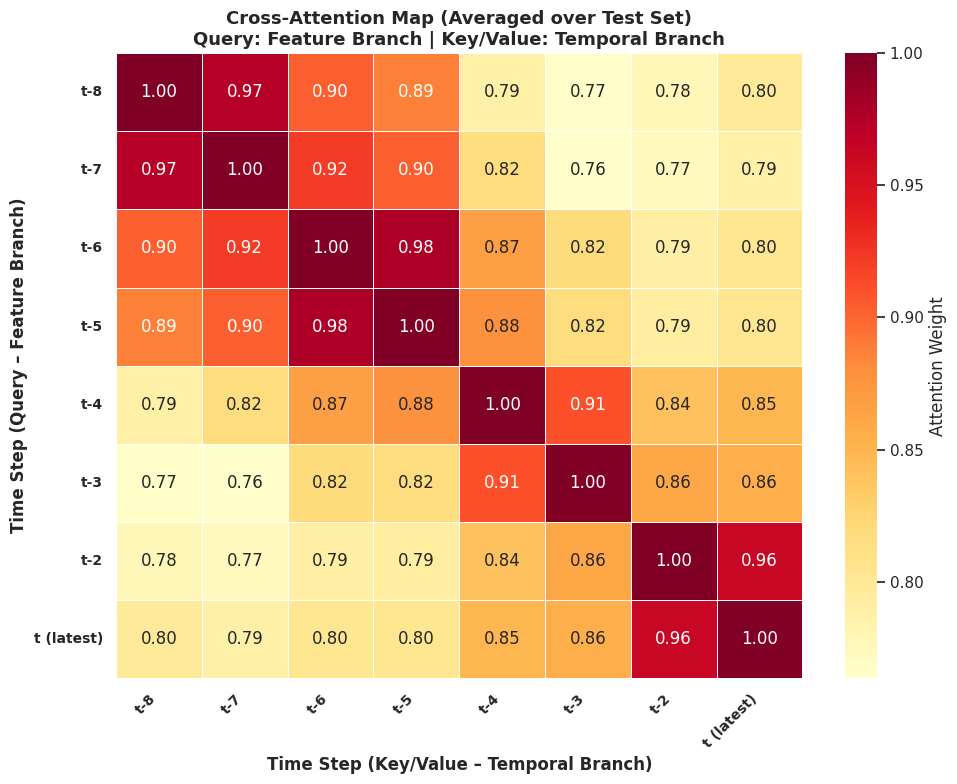

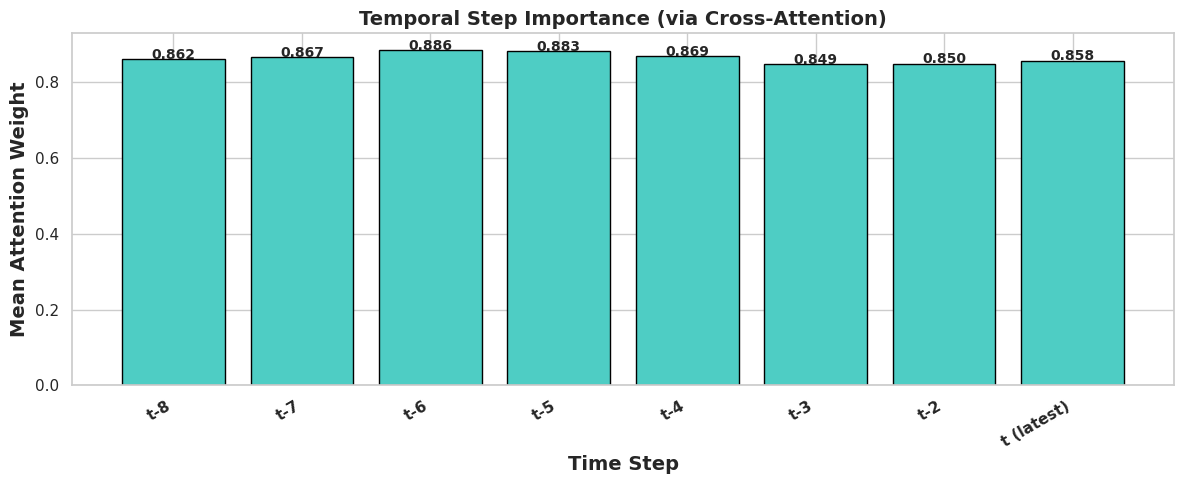

In [29]:
# ─────────────────────────────────────────────
# SECTION 15: XAI – Attention Rollout Heatmap
# ─────────────────────────────────────────────
print("\n[XAI] Extracting Attention Rollout Heatmaps...")
SEQ_LEN = 8
feature_names = X_train.columns.tolist()
print(feature_names)
model.eval()

attn_maps_all = []   # collect over test batches
with torch.no_grad():
    for batch_x, batch_y in test_loader:
        _ = model(batch_x)
        attn_maps_all.append(model.last_attn_weights.cpu().numpy())  # [B, T, T]

attn_maps_all = np.concatenate(attn_maps_all, axis=0)   # [N, T, T]

# Global: mean cross-attention over test set
mean_attn = attn_maps_all.mean(axis=0)    # [T, T]

# ── أسماء خطوات الزمن بدل الأرقام ──
time_step_labels = [f"t-{SEQ_LEN - i}" if i < SEQ_LEN - 1 else "t (latest)"
                    for i in range(SEQ_LEN)]

fig, ax = plt.subplots(figsize=(10, 8))
sns.heatmap(mean_attn, cmap='YlOrRd', annot=True, fmt='.2f',
            linewidths=0.5, ax=ax, cbar_kws={'label': 'Attention Weight'},
            xticklabels=time_step_labels,   # ← أسماء محور X
            yticklabels=time_step_labels)   # ← أسماء محور Y
ax.set_title('Cross-Attention Map (Averaged over Test Set)\n'
             'Query: Feature Branch | Key/Value: Temporal Branch',
             fontsize=13, fontweight='bold')
ax.set_xlabel('Time Step (Key/Value – Temporal Branch)', fontsize=12, fontweight='bold')
ax.set_ylabel('Time Step (Query – Feature Branch)',       fontsize=12, fontweight='bold')
ax.set_xticklabels(ax.get_xticklabels(), rotation=45, ha='right', fontsize=10, fontweight='bold')
ax.set_yticklabels(ax.get_yticklabels(), rotation=0,   fontsize=10, fontweight='bold')
plt.tight_layout()
plt.savefig('attention_heatmap.png', dpi=300, bbox_inches='tight')
plt.show()

# Per-time-step importance vector – بأسماء الخطوات
time_importance = mean_attn.mean(axis=0)   # [T]
fig, ax = plt.subplots(figsize=(12, 5))
bars = ax.bar(time_step_labels, time_importance, color='#4ECDC4', edgecolor='black')
for bar, val in zip(bars, time_importance):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.001,
            f'{val:.3f}', ha='center', fontsize=10, fontweight='bold')
ax.set_xlabel('Time Step', fontsize=14, fontweight='bold')
ax.set_ylabel('Mean Attention Weight', fontsize=14, fontweight='bold')
ax.set_title('Temporal Step Importance (via Cross-Attention)',
             fontsize=14, fontweight='bold')
ax.set_xticklabels(time_step_labels, rotation=30, ha='right', fontsize=11, fontweight='bold')
plt.tight_layout(); plt.show()



[XAI] SHAP Gradient Explainer...
shap_values shape after normalization: (50, 8, 16)


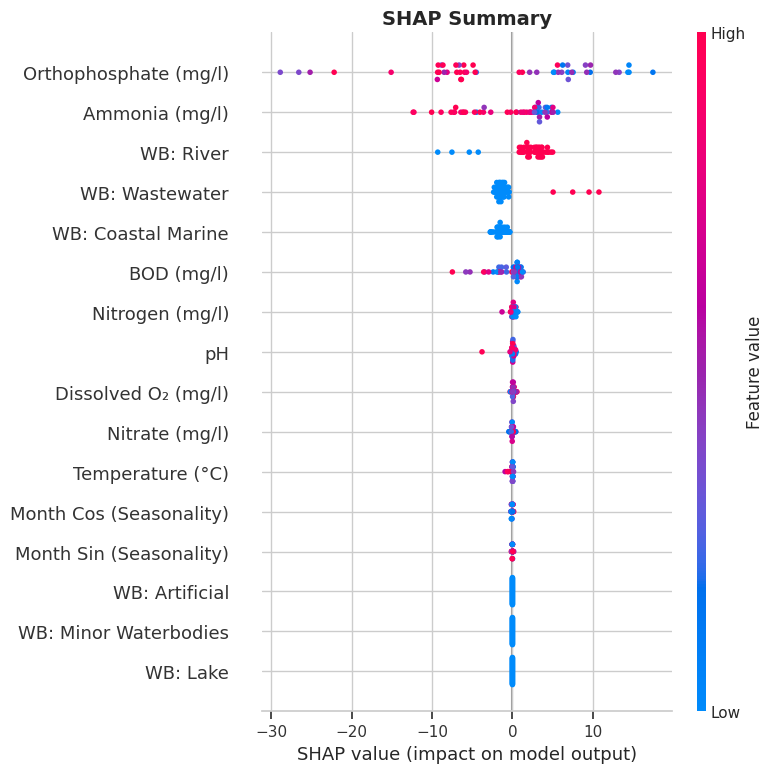

shap_means shape: (16,) | len features: 16


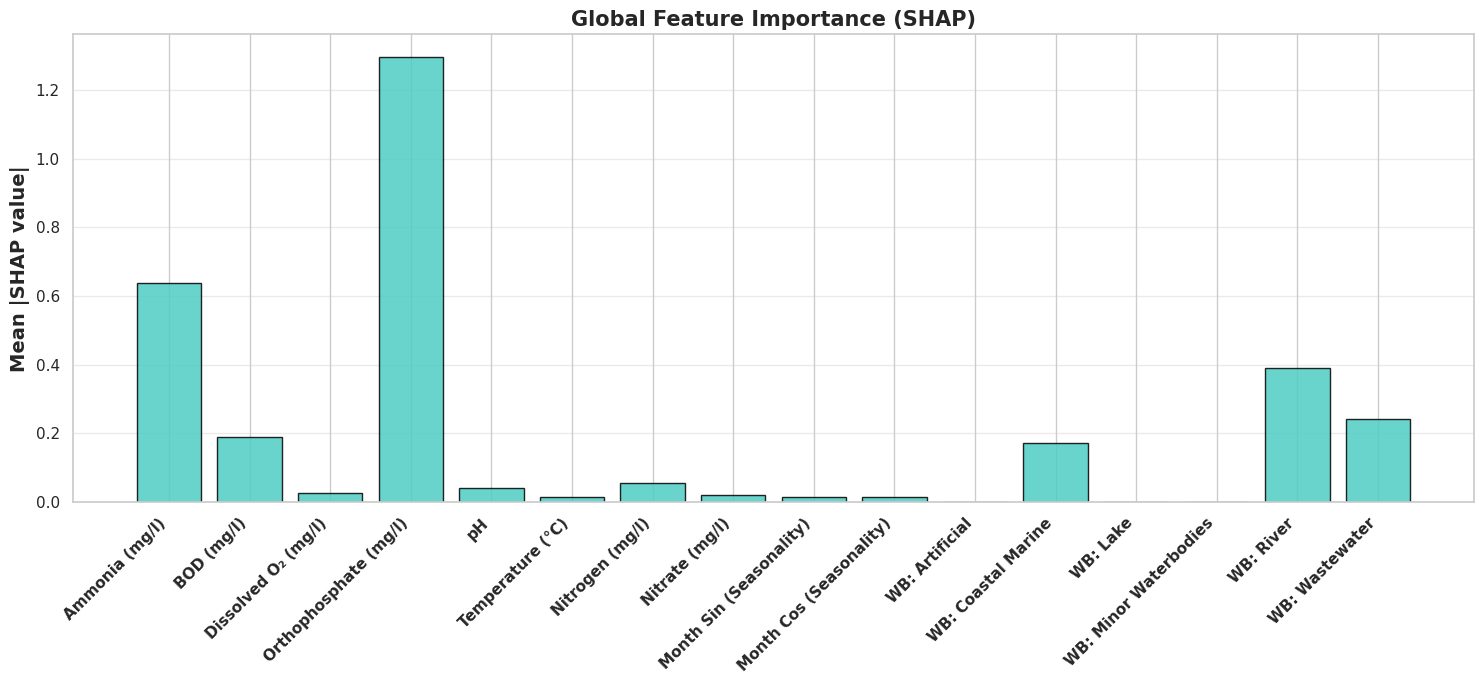

In [30]:

# ─────────────────────────────────────────────
# SECTION 16: XAI – SHAP GradientExplainer
# ─────────────────────────────────────────────
import shap
import numpy as np

print("\n[XAI] SHAP Gradient Explainer...")
background  = X_train_t[:100].to(device)
explainer   = shap.GradientExplainer(model, background)
test_sample = X_test_t[:50]   # already on device

shap_raw = explainer.shap_values(test_sample)

# ──────────────────────────────────────────────────────────────────────
# ✅ ROBUST FIX: Normalize shap_values to shape [N, T, F] regardless of
# what SHAP version returns. Possible raw shapes:
#   • list of [N, T, F]        ← SHAP < 0.40
#   • list of [N, T, F, 1]     ← SHAP 0.40-0.41
#   • ndarray [N, T, F]        ← some versions
#   • ndarray [N, T, F, 1]     ← other versions
# ──────────────────────────────────────────────────────────────────────
def normalize_shap(sv):
    """Always returns a plain float64 ndarray of shape [N, T, F]."""
    # Step 1: unwrap list → take first element (single-output model)
    if isinstance(sv, list):
        sv = sv[0]
    # Step 2: convert to numpy float64 (handles torch tensors too)
    sv = np.asarray(sv, dtype=np.float64)
    # Step 3: squeeze any trailing size-1 dims until we reach 3D [N, T, F]
    while sv.ndim > 3:
        if sv.shape[-1] == 1:
            sv = sv[..., 0]   # drop trailing output-dim
        elif sv.shape[0] == 1:
            sv = sv[0]        # drop leading wrapper-dim
        else:
            break             # unexpected shape — stop and let print below show it
    return sv

shap_values = normalize_shap(shap_raw)
print(f"shap_values shape after normalization: {shap_values.shape}")
# Expected: (50, 8, F)  where F = number of features
assert shap_values.ndim == 3, f"Unexpected SHAP shape: {shap_values.shape}"

# ── Feature name mapping ─────────────────────────────────────────────
raw_feature_names = X_train.columns.tolist()
feature_name_map = {
    'Ammonia_mg_l':                    'Ammonia (mg/l)',
    'Biochemical_Oxygen_Demand_mg_l':  'BOD (mg/l)',
    'Dissolved_Oxygen_mg_l':           'Dissolved O₂ (mg/l)',
    'Orthophosphate_mg_l':             'Orthophosphate (mg/l)',
    'pH_ph_units':                     'pH',
    'Temperature_cel':                 'Temperature (°C)',
    'Nitrogen_mg_l':                   'Nitrogen (mg/l)',
    'Nitrate_mg_l':                    'Nitrate (mg/l)',
    'Month_sin':                       'Month Sin (Seasonality)',
    'Month_cos':                       'Month Cos (Seasonality)',
}
feature_names_display = [
    feature_name_map.get(c, c.replace('_', ' ').replace('Waterbody Type ', 'WB: '))
    for c in raw_feature_names
]

# ── SHAP Summary Plot ────────────────────────────────────────────────
test_np  = test_sample.cpu().numpy()
input_2d = test_np.mean(axis=1)       # [50, T, F] → mean over T → [50, F]
sv_2d    = shap_values.sum(axis=1)    # [50, T, F] → sum  over T → [50, F]

plt.figure(figsize=(11, 7))
shap.summary_plot(sv_2d, input_2d, feature_names=feature_names_display, show=False)
plt.title("SHAP Summary", fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('shap_summary.png', dpi=300, bbox_inches='tight')
plt.show()

# ── Global Feature Importance Bar ───────────────────────────────────
# mean over N (samples) and T (time steps) → 1-D array of shape [F]
shap_means = np.abs(shap_values).mean(axis=(0, 1)).flatten()  # always 1-D ✅
print(f"shap_means shape: {shap_means.shape} | len features: {len(feature_names_display)}")

fig, ax = plt.subplots(figsize=(15, 7))
x = np.arange(len(feature_names_display))
ax.bar(x, shap_means, color='#4ECDC4', edgecolor='black', alpha=0.85)

ax.set_ylabel('Mean |SHAP value|', fontsize=14, fontweight='bold')
ax.set_title('Global Feature Importance (SHAP)', fontsize=15, fontweight='bold')
ax.set_xticks(x)
ax.set_xticklabels(feature_names_display, rotation=45, ha='right',
                   fontsize=11, fontweight='bold')
ax.grid(axis='y', alpha=0.4)
plt.tight_layout()
plt.savefig('global_feature_importance_shap.png', dpi=300, bbox_inches='tight')
plt.show()


In [31]:

# ─────────────────────────────────────────────
# SECTION 17: XAI – Local Explanation Report
# ─────────────────────────────────────────────
print("\n[XAI] Local Explanations (5 test samples):")
print("="*80)

for sample_idx in range(5):
    true_val = t_targets[sample_idx]
    pred_val = t_preds[sample_idx]

    # Feature importance summed across time
    sv = shap_values[sample_idx]         # [T, F]
    sv_sum = sv.sum(axis=0)              # [F]
    top_k  = np.argsort(np.abs(sv_sum))[::-1][:3] # top-3

    top_feats = [(feature_names_display[i], sv_sum[i]) for i in top_k]
    feat_str  = ", ".join([f"{n}({'↑' if v > 0 else '↓'}{abs(v):.3f})"
                           for n, v in top_feats])

    print(f"Sample {sample_idx+1}: True CCME={true_val:.2f} | Pred={pred_val:.2f}")
    print(f"   → Key drivers: {feat_str}\n")




[XAI] Local Explanations (5 test samples):
Sample 1: True CCME=89.63 | Pred=90.25
   → Key drivers: Orthophosphate (mg/l)(↑6.246), Ammonia (mg/l)(↑2.770), WB: River(↑2.092)

Sample 2: True CCME=89.63 | Pred=91.30
   → Key drivers: Orthophosphate (mg/l)(↑5.200), Ammonia (mg/l)(↑2.254), WB: River(↑2.225)

Sample 3: True CCME=74.34 | Pred=76.32
   → Key drivers: Orthophosphate (mg/l)(↓4.495), WB: River(↑2.839), Ammonia (mg/l)(↑2.605)

Sample 4: True CCME=71.68 | Pred=75.06
   → Key drivers: Orthophosphate (mg/l)(↓8.825), WB: River(↑2.298), Ammonia (mg/l)(↑2.111)

Sample 5: True CCME=71.74 | Pred=75.93
   → Key drivers: Orthophosphate (mg/l)(↓6.642), WB: River(↑3.119), Ammonia (mg/l)(↑2.313)



In [32]:

# ─────────────────────────────────────────────
# SECTION 18: DiCE – Counterfactual Explanations
# ─────────────────────────────────────────────
# DiCE for Regression is possible but requires different parameters.
# Disabled for now.
print("\n[DiCE] Disabled for regression.")




[DiCE] Disabled for regression.



ABLATION STUDY — CNN-CRNN-M5T Components
  [CNN only]  RMSE=3.3301  MAE=2.4477
  [CRNN only]  RMSE=6.1084  MAE=5.2250
  [CNN-CRNN]  RMSE=8.4938  MAE=7.9748
  [CNN-M5T]  RMSE=2.6059  MAE=1.8311
  [CRNN-M5T]  RMSE=5.9202  MAE=5.1830
  [CNN-CRNN-M5T (Full)]  RMSE=6.3963  MAE=6.0416


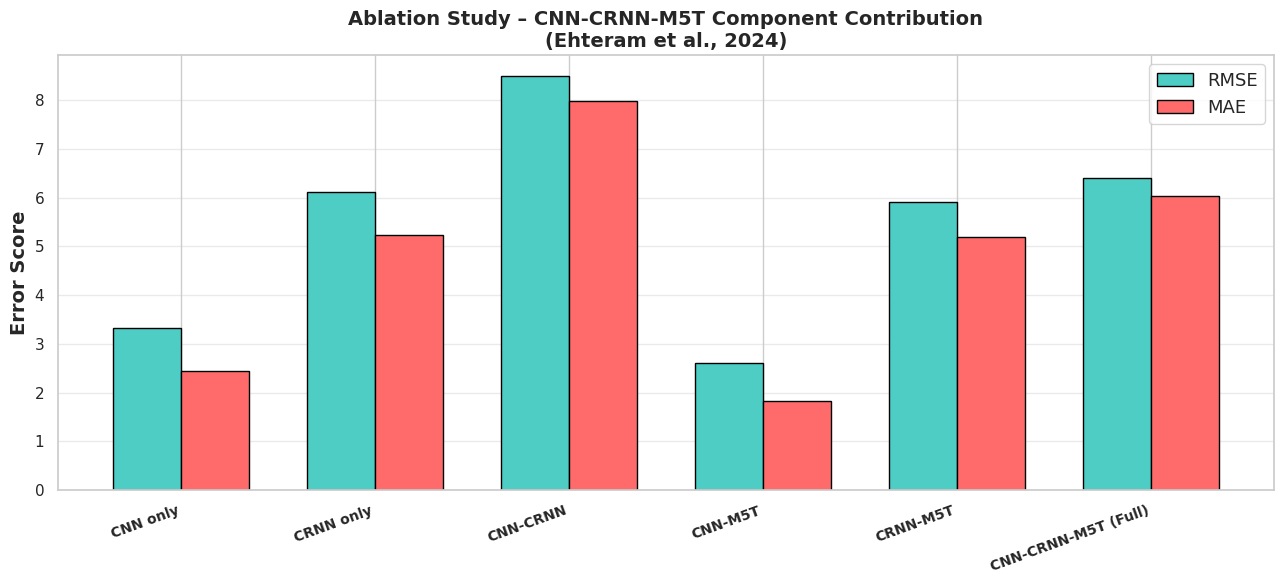

In [33]:
# ─────────────────────────────────────────────
# SECTION 19: Ablation Study
#   CNN-only | CRNN-only | CNN+CRNN (no M5T) | Full CNN-CRNN-M5T
# ─────────────────────────────────────────────
print("\n" + "="*80)
print("ABLATION STUDY — CNN-CRNN-M5T Components")
print("="*80)


class AblationModel(nn.Module):
    """
    Ablation variants of CNN-CRNN-M5T.
    Mirrors the paper's comparison:
      CNN only | CRNN only | CNN-CRNN | CNN-M5T | CRNN-M5T | CNN-CRNN-M5T
    """
    def __init__(self, input_dim,
                 use_cnn=True, use_crnn=True, use_m5t=True,
                 cnn_dim=64, crnn_hidden=64, n_groups=4,
                 tree_depth=2, output_dim=1, dropout=0.15):
        super().__init__()
        self.use_cnn  = use_cnn
        self.use_crnn = use_crnn
        self.use_m5t  = use_m5t

        out_dim_cnn  = cnn_dim        if use_cnn  else input_dim
        out_dim_crnn = crnn_hidden    if use_crnn else out_dim_cnn
        final_dim    = out_dim_crnn

        if use_cnn:
            self.cnn = CNNSpatialExtractor(
                input_dim=input_dim, cnn_dim=cnn_dim,
                num_conv_layers=2, dropout=dropout
            )
        if use_crnn:
            self.crnn = ClockworkRNN(
                input_dim=out_dim_cnn, hidden_dim=crnn_hidden,
                n_groups=n_groups, dropout=dropout
            )
        if use_m5t:
            self.m5tree = M5TreeHead(
                input_dim=final_dim, depth=tree_depth, output_dim=output_dim
            )
        else:
            self.regressor = nn.Sequential(
                nn.Linear(final_dim, final_dim // 2),
                nn.ReLU(),
                nn.Dropout(dropout),
                nn.Linear(final_dim // 2, output_dim)
            )
        self.pool = nn.AdaptiveAvgPool1d(1)

    def forward(self, x):
        out = x
        if self.use_cnn:
            out = self.cnn(out)
        if self.use_crnn:
            out = self.crnn(out)
        # pool over time
        pooled = self.pool(out.permute(0, 2, 1)).squeeze(-1)
        if self.use_m5t:
            return self.m5tree(pooled)
        return self.regressor(pooled)


def quick_train_eval(model_v, name, epochs=4):
    opt  = optim.AdamW(model_v.parameters(), lr=1e-3, weight_decay=1e-4)
    crit = nn.MSELoss()
    for ep in range(epochs):
        model_v.train()
        for bx, by in train_loader:
            bx = bx.to(device); by = by.to(device)
            loss = crit(model_v(bx), by)
            opt.zero_grad(); loss.backward(); opt.step()
    model_v.eval()
    preds_all, targs_all = [], []
    with torch.no_grad():
        for bx, by in test_loader:
            preds_all.extend(model_v(bx).cpu().numpy().flatten())
            targs_all.extend(by.cpu().numpy().flatten())
    rmse = np.sqrt(mean_squared_error(targs_all, preds_all))
    mae  = mean_absolute_error(targs_all, preds_all)
    print(f"  [{name}]  RMSE={rmse:.4f}  MAE={mae:.4f}")
    return rmse, mae


# Ablation configs — mirrors paper Table comparisons
configs = [
    ("CNN only",          True,  False, False),
    ("CRNN only",         False, True,  False),
    ("CNN-CRNN",          True,  True,  False),
    ("CNN-M5T",           True,  False, True),
    ("CRNN-M5T",          False, True,  True),
    ("CNN-CRNN-M5T (Full)", True, True, True),
]

ablation_results = {}
for name, uc, ur, um in configs:
    m_abl = AblationModel(
        input_size, use_cnn=uc, use_crnn=ur, use_m5t=um,
        cnn_dim=64, crnn_hidden=64, n_groups=4,
        tree_depth=2, output_dim=1, dropout=0.15
    ).to(device)
    rmse, mae = quick_train_eval(m_abl, name, epochs=4)
    ablation_results[name] = {'RMSE': rmse, 'MAE': mae}

labels    = list(ablation_results.keys())
rmse_vals = [ablation_results[k]['RMSE'] for k in labels]
mae_vals  = [ablation_results[k]['MAE']  for k in labels]

x = np.arange(len(labels)); w = 0.35
fig, ax = plt.subplots(figsize=(13, 6))
ax.bar(x - w/2, rmse_vals, w, label='RMSE', color='#4ECDC4', edgecolor='black')
ax.bar(x + w/2, mae_vals,  w, label='MAE',  color='#FF6B6B', edgecolor='black')
ax.set_xticks(x)
ax.set_xticklabels(labels, fontsize=10, fontweight='bold', rotation=20, ha='right')
ax.set_ylabel('Error Score', fontsize=14, fontweight='bold')
ax.set_title('Ablation Study – CNN-CRNN-M5T Component Contribution\n'
             '(Ehteram et al., 2024)', fontsize=14, fontweight='bold')
ax.legend(fontsize=13); ax.grid(axis='y', alpha=0.4)
plt.tight_layout()
plt.savefig('ablation_study.png', dpi=300, bbox_inches='tight')
plt.show()


In [34]:

# ─────────────────────────────────────────────
# SECTION 20: Final Summary
# ─────────────────────────────────────────────
print("\n" + "="*80)
print(" FINAL MODEL PERFORMANCE SUMMARY – CNN-CRNN-M5T (Ehteram et al., 2024)")
print("="*80)
print(f"  Test MSE:   {test_mse:>8.4f}")
print(f"  Test RMSE:  {test_rmse:>8.4f}")
print(f"  Test MAE:   {test_mae:>8.4f}")
print(f"  R2 Score:   {test_r2:>8.4f}")
print("="*80)




 FINAL MODEL PERFORMANCE SUMMARY – CNN-CRNN-M5T (Ehteram et al., 2024)
  Test MSE:    13.1089
  Test RMSE:    3.6206
  Test MAE:     3.1330
  R2 Score:     0.9516


In [35]:
# End of notebook — Dual-Branch Transformer Regression on CCME_Values
